# 路径与依赖导入

1.导入必要库：pandas、numpy、sklearn、tensorflow.keras

定义三份核心文件路径：

PATH_MBTI：MBTI+成绩预测结果

PATH_BATCH：上海投档线

PATH_MAJOR：上海专业分数线

数据读取与初步检查

读取三份 Excel（read_excel）

打印 df_scores.columns、df_batch.columns、df_major.columns

检查缺失、类型（dtypes）

2.数据清洗与预处理

强制成绩列转 float（to_numeric(errors='coerce')）

填补 “总分_plus60” 列

去除不必要列（如姓名或敏感信息）

重置索引

特征与标签构造

特征矩阵 X：八科成绩 → 三维张量 (n, 1, features)

目标 y：总分_plus60 或后续“位次”

3.核心算法实现与训练
LSTM 成绩/位次预测

模型定义：Sequential([Input, LSTM, Dense, Dense])

编译：optimizer='adam'、loss='mse'、metrics=['mae']

训练：fit(X_train, y_train, epochs, batch_size, validation_split)

评估：evaluate(X_test, y_test)

4.协同过滤兴趣/院校推荐

构建用户—内容交互矩阵：学生 × 院校/专业

调用 Surprise 或 implicit 包做 SVD/ALS 分解

生成 Top-N 推荐列表

逻辑回归录取概率预测

准备特征：合并 df_batch、df_major 的分数线与位次数据

构建 LogisticRegression 模型

训练与交叉验证

输出概率分值

MBTI/兴趣加权排序

加载或定义院校—MBTI 匹配字典

为每条推荐加分：高度匹配 +1，一般匹配 +0.5，低匹配 +0

最终按“录取概率 × MBTI 适配度”排序

5.结果合并与导出
投档线合并

将 df_scores 与 df_batch 按 年份 + 目标院校 进行 merge

标注：是否过投档线_按分数 和 是否过投档线_按位次

专业线合并（可选）

同理合并 df_major（按 年份 + 院校 + 专业）

标注：可录取专业

批量志愿推荐表生成

遍历每位学生：筛选所有 最低分 ≤ 学生分数 的院校/专业

分层 “冲/稳/保” 并附加 MBTI 匹配度

汇总为 DataFrame，按 考号 + 推荐档 排序

导出 Excel

to_excel("批量志愿推荐_MBTI匹配结果.xlsx", index=False)

6. 模型评估与验证
数值指标

LSTM：MSE、MAE、R²

逻辑回归：AUC、KS

CF 推荐：Precision@N、Recall@N、nDCG

可视化分析

绘制训练/验证损失曲线

ROC 曲线、推荐质量曲线

用户反馈（模拟）

构造简单问卷结果示例

打印“用户满意度”统计

## 1.导入必要库：pandas、numpy、sklearn、tensorflow.keras

定义三份核心文件路径：

PATH_MBTI：MBTI+成绩预测结果

PATH_BATCH：上海投档线

PATH_MAJOR：上海专业分数线

数据读取与初步检查

读取三份 Excel（read_excel）

打印 df_scores.columns、df_batch.columns、df_major.columns

检查缺失、类型（dtypes）

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models


In [2]:
# 1. 定义三份核心文件路径
PATH_MBTI  = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\二模_MBTI_预测结果_plus60.xlsx")
PATH_BATCH = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\上海_投档线_2017-2023\2023上海投档线.xlsx")
PATH_MAJOR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\上海_专业分数线_2017-2023\2023上海专业分数线.xlsx")

In [3]:
# 2. 数据读取
df_scores = pd.read_excel(PATH_MBTI, engine="openpyxl")
df_batch  = pd.read_excel(PATH_BATCH, engine="openpyxl")
df_major  = pd.read_excel(PATH_MAJOR, engine="openpyxl")

C:\Users\Lenovo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\Lenovo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [4]:
# 3. 打印列名
print("df_scores.columns:", df_scores.columns.tolist())
print("df_batch.columns:", df_batch.columns.tolist())
print("df_major.columns:", df_major.columns.tolist())


df_scores.columns: ['学校', '班级', '姓名', '考号', '总分分数', '语数外分数', '语文分数', '数学分数', '英语分数', '政治分数', '历史分数', '物理分数', '化学分数', '生物(生命科学)分数', 'top2', 'MBTI_初判', '总分_plus60']
df_batch.columns: ['年份', '生源地', '学校', '省份', '城市', '软科排名', '985', '211', '双一流', '科类', '批次', '专业组', '选科要求', '最低分', '最低分排名', '省控线', '办学性质', '学校归属', '学历类别']
df_major.columns: ['年份', '生源地', '科类', '批次', '院校名称', '专业名称', '专业备注', '最低分', '最低位次', '最高分', '平均分']


In [5]:
# 4. 检查数据类型
print("\ndf_scores.dtypes:\n", df_scores.dtypes)
print("\ndf_batch.dtypes:\n",  df_batch.dtypes)
print("\ndf_major.dtypes:\n",  df_major.dtypes)


df_scores.dtypes:
 学校             object
班级             object
姓名             object
考号            float64
总分分数          float64
语数外分数         float64
语文分数            int64
数学分数            int64
英语分数          float64
政治分数          float64
历史分数          float64
物理分数          float64
化学分数          float64
生物(生命科学)分数    float64
top2           object
MBTI_初判        object
总分_plus60     float64
dtype: object

df_batch.dtypes:
 年份        int64
生源地      object
学校       object
省份       object
城市       object
软科排名     object
985      object
211      object
双一流      object
科类       object
批次       object
专业组      object
选科要求     object
最低分       int64
最低分排名     int64
省控线      object
办学性质     object
学校归属     object
学历类别     object
dtype: object

df_major.dtypes:
 年份       int64
生源地     object
科类      object
批次      object
院校名称    object
专业名称    object
专业备注    object
最低分      int64
最低位次    object
最高分      int64
平均分      int64
dtype: object


In [6]:
# 5. 检查缺失值
print("\nMissing values in df_scores:\n", df_scores.isnull().sum())
print("\nMissing values in df_batch:\n",  df_batch.isnull().sum())
print("\nMissing values in df_major:\n",  df_major.isnull().sum())


Missing values in df_scores:
 学校              0
班级              0
姓名              0
考号            229
总分分数            0
语数外分数          42
语文分数            0
数学分数            0
英语分数           42
政治分数           82
历史分数           96
物理分数          128
化学分数          162
生物(生命科学)分数    229
top2            8
MBTI_初判         8
总分_plus60       0
dtype: int64

Missing values in df_batch:
 年份        0
生源地       0
学校        0
省份        0
城市        0
软科排名      0
985       0
211       0
双一流       0
科类        0
批次        0
专业组       0
选科要求      0
最低分       0
最低分排名     0
省控线       0
办学性质      0
学校归属     42
学历类别     42
dtype: int64

Missing values in df_major:
 年份      0
生源地     0
科类      0
批次      0
院校名称    0
专业名称    0
专业备注    0
最低分     0
最低位次    0
最高分     0
平均分     0
dtype: int64


In [7]:
# 1) 对 df_scores 的数值列做插补
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df_scores[ ['语数外分数','英语分数','政治分数','历史分数','物理分数','化学分数'] ] = \
    imputer.fit_transform(df_scores[ ['语数外分数','英语分数','政治分数','历史分数','物理分数','化学分数'] ])

# 2) 对全空的“生物(生命科学)分数”直接删除这一列
df_scores = df_scores.drop(columns=['生物(生命科学)分数'])

# 3) 如果“考号”确实缺失，可改用“姓名+班级”拼接生成临时 ID
df_scores['student_id'] = df_scores['班级'].astype(str) + '_' + df_scores['姓名'].astype(str)

# 4) 重新构造特征，保证每行至少有 2 门选考科成绩参与 top2 & LSTM


### 2.数据清洗与预处理

强制成绩列转 float（to_numeric(errors='coerce')）

填补 “总分_plus60” 列

去除不必要列（如姓名或敏感信息）

重置索引

特征与标签构造

特征矩阵 X：八科成绩 → 三维张量 (n, 1, features)

目标 y：总分_plus60 或后续“位次”

In [8]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from pathlib import Path

In [9]:
# === 读取原始成绩表 ===
PATH_MBTI = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\二模_MBTI_预测结果_plus60.xlsx")
df_scores = pd.read_excel(PATH_MBTI, engine="openpyxl")


In [10]:
#2. 数据清洗与预处理
# 假设 df_scores 已读取
# 强制各科成绩列转换为 float
SUBJECT_COLS = [
    '语文分数', '数学分数', '英语分数',
    '政治分数', '历史分数', '物理分数',
    '化学分数', '生物(生命科学)分数'
]
for col in SUBJECT_COLS:
    df_scores[col] = pd.to_numeric(df_scores[col], errors='coerce')


In [11]:
# 强制各科成绩列转换为 float
# 3) 强制类型转换 (只保留一次转换即可)
for col in SUBJECT_COLS: # 将 subject_cols 改为 SUBJECT_COLS
    df_scores[col] = pd.to_numeric(df_scores[col], errors='coerce')

In [12]:
# 4) 数值列插补（中位数，仅对存在的科目列做）
# 注意：这里 elec_cols 定义的科目列表与 SUBJECT_COLS 部分重叠且有所不同
# 如果 '语数外分数' 是一个总分，而你的数据中没有这个列，那么它不会被处理
elec_cols = [c for c in ['语数外分数','英语分数','政治分数','历史分数','物理分数','化学分数']
             if c in df_scores.columns]
if elec_cols:
    imputer = SimpleImputer(strategy='median')
    df_scores[elec_cols] = imputer.fit_transform(df_scores[elec_cols])

print("代码运行成功，没有NameError。")

代码运行成功，没有NameError。


In [13]:
# 5) 删除全空的“生物”列（如存在）
bio_col = '生物(生命科学)分数'

# 确保 SUBJECT_COLS 在这里可用，通常它是在文件顶部定义的全局变量
# 如果你只是运行了这一小段代码，而没有运行定义 SUBJECT_COLS 的那一部分，
# 那么 SUBJECT_COLS 也可能未定义。请确保你的上下文是完整的。

# 假设 SUBJECT_COLS 已经定义并包含所有科目：
# SUBJECT_COLS = [
#     '语文分数', '数学分数', '英语分数',
#     '政治分数', '历史分数', '物理分数',
#     '化学分数', '生物(生命科学)分数' # 包含生物
# ]

if bio_col in df_scores.columns and df_scores[bio_col].isna().all():
    df_scores.drop(columns=[bio_col], inplace=True)
    # 仅当 bio_col 确实在 SUBJECT_COLS 中时再移除
    if bio_col in SUBJECT_COLS: # <-- 将 subject_cols 改为 SUBJECT_COLS
        SUBJECT_COLS.remove(bio_col) # <-- 将 subject_cols.remove 改为 SUBJECT_COLS.remove

print("代码运行成功，没有NameError。")

代码运行成功，没有NameError。


In [14]:
# 6) 生成 student_id（若考号全空则用 班级+姓名，否则用 考号）
if '考号' in df_scores.columns and df_scores['考号'].notna().any():
    df_scores['student_id'] = df_scores['考号']
else:
    df_scores['student_id'] = (
        df_scores['班级'].astype(str) + '_' + df_scores['姓名'].astype(str)
    )

In [15]:
# 7) 删除敏感列
for drop_col in ['姓名']:
    if drop_col in df_scores.columns:
        df_scores.drop(columns=[drop_col], inplace=True)

# 8) 重置索引
df_scores.reset_index(drop=True, inplace=True)

# 9) 删除缺失过多的行：至少保留 科目+“总分_plus60” 中 len(existing)-1 列非空
required = SUBJECT_COLS + ['总分_plus60'] # <-- 将 subject_cols 改为 SUBJECT_COLS
existing = [c for c in required if c in df_scores.columns]
df_clean = df_scores.dropna(axis=0, thresh=len(existing)-1, subset=existing).reset_index(drop=True)


In [16]:
# 10) 构造特征与标签
FEATURE_COLS = [c for c in SUBJECT_COLS if c in df_clean.columns]
X = df_clean[FEATURE_COLS].astype('float32').values[:, None, :]
y = pd.to_numeric(df_clean['总分_plus60'], errors='coerce').astype('float32').values


In [17]:
# 11) 检查输出
print("清洗后样本数:", X.shape[0])
print("X 形状:", X.shape)
print("y 形状:", y.shape)

清洗后样本数: 229
X 形状: (229, 1, 7)
y 形状: (229,)


In [58]:
# === 数据处理函数，后续可复用 ===
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
def make_xy(df_sub, feature_cols, label_col):
    X = df_sub[feature_cols].astype('float32').values
    y = df_sub[label_col].values.astype('float32')
    return X, y

In [59]:
#数据可视化
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import font_manager
# 中文字体设置（防止乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# Seaborn 样式美化
sns.set_style("whitegrid")

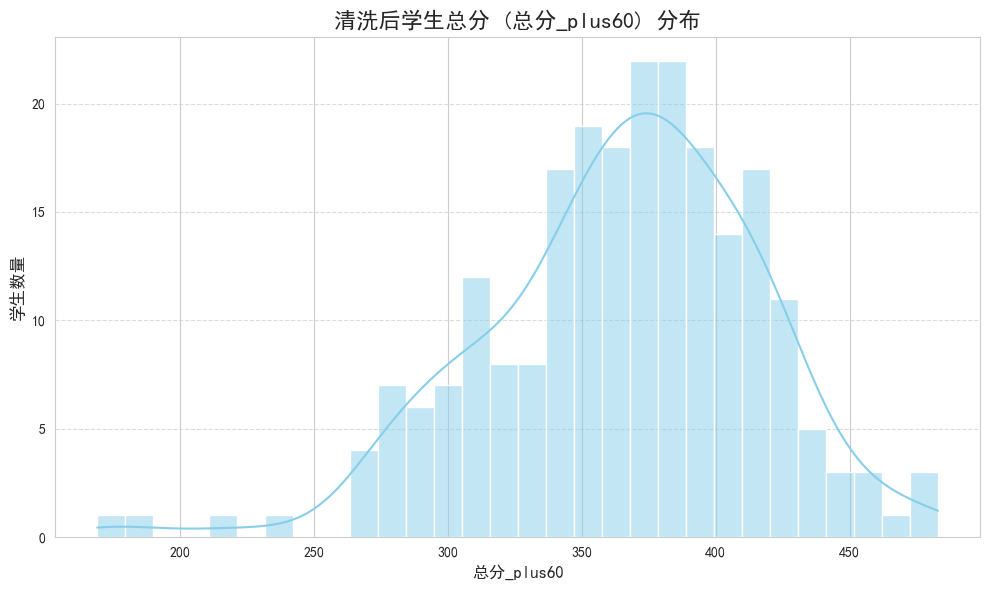

In [60]:
# 2.1 绘制目标变量“总分_plus60”的分布图
# 2. 设置字体（路径设置比名字更强制有效）
font_path = "C:/Windows/Fonts/simhei.ttf"  # SimHei 黑体常见路径
simhei_font = font_manager.FontProperties(fname=font_path)
rcParams['font.family'] = simhei_font.get_name()  # 确保使用 SimHei
rcParams['axes.unicode_minus'] = False

if '总分_plus60' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_clean['总分_plus60'], kde=True, bins=30, color='skyblue')
    plt.title('清洗后学生总分 (总分_plus60) 分布', fontsize=16)
    plt.xlabel('总分_plus60', fontsize=12)
    plt.ylabel('学生数量', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("列 '总分_plus60' 不存在，请检查 df_clean 数据。")

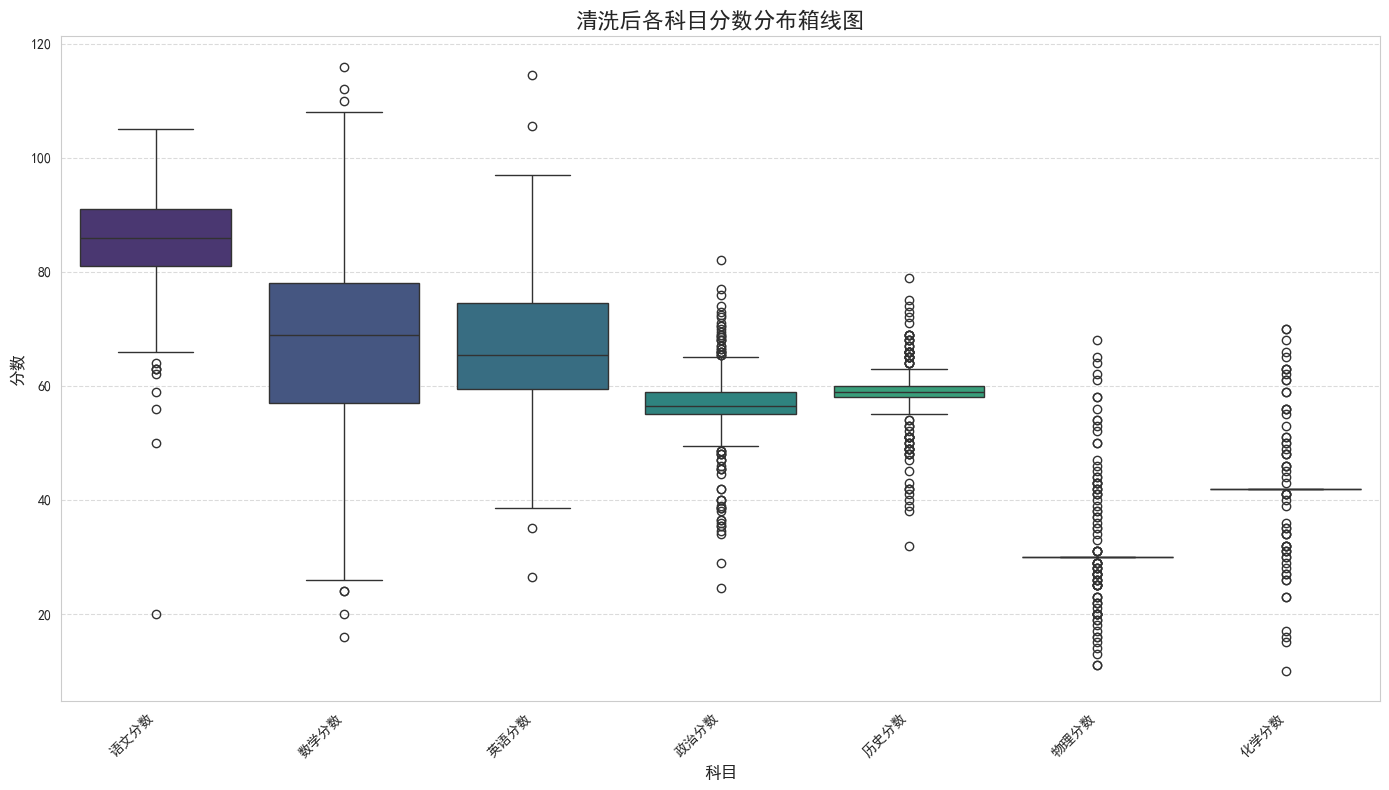

In [61]:
#2.2 各科目分数的分布（箱线图）
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rcParams

# 1. 设置中文字体（黑体）防止警告
font_path = "C:/Windows/Fonts/simhei.ttf"  # SimHei 黑体
simhei_font = font_manager.FontProperties(fname=font_path)
rcParams['font.family'] = simhei_font.get_name()
rcParams['axes.unicode_minus'] = False

# 2. 确保 FEATURE_COLS 正确存在
if 'FEATURE_COLS' in locals() and all(col in df_clean.columns for col in FEATURE_COLS):
    plt.figure(figsize=(14, 8))
    sns.boxplot(data=df_clean[FEATURE_COLS], palette='viridis')
    plt.title('清洗后各科目分数分布箱线图', fontsize=16)
    plt.xlabel('科目', fontsize=12)
    plt.ylabel('分数', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("ERROR: FEATURE_COLS 未定义或包含无效列。请检查 FEATURE_COLS 和 df_clean。")



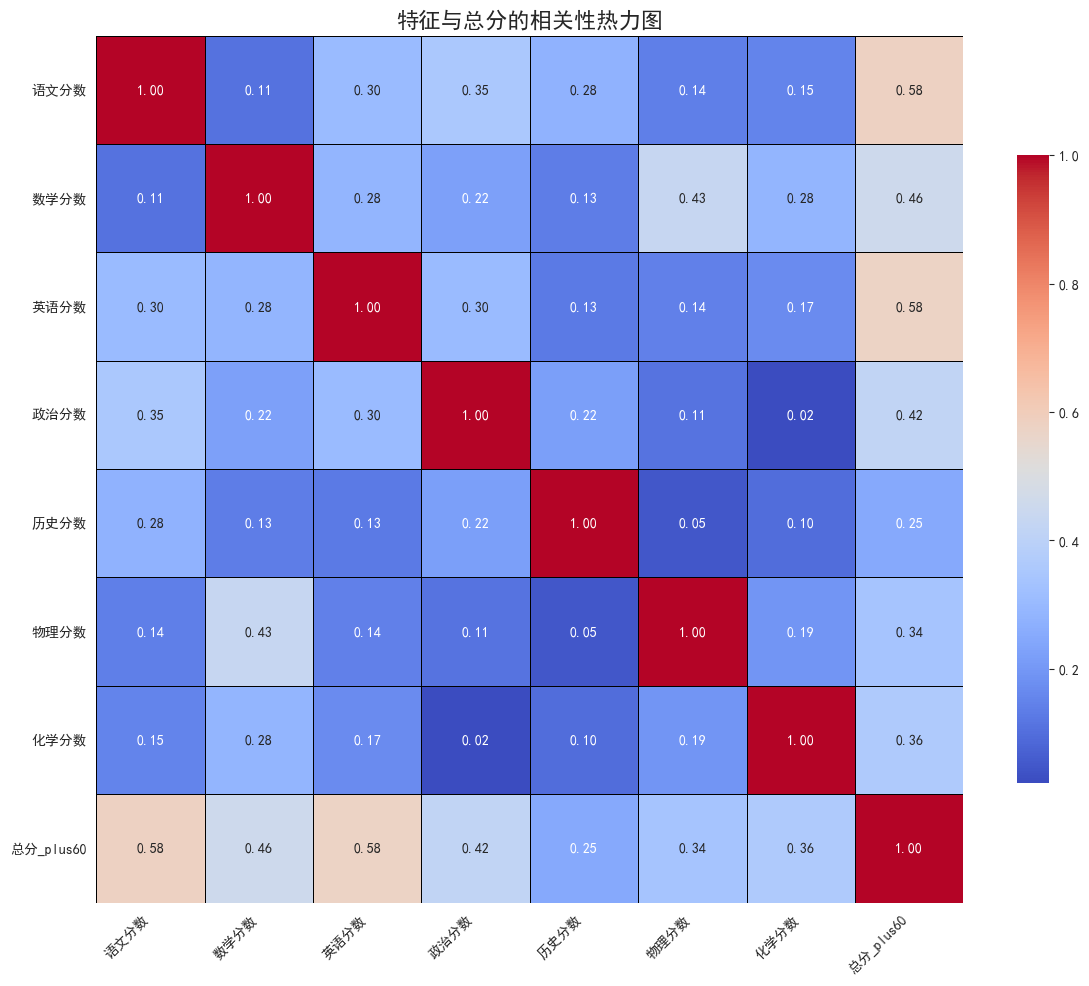

In [62]:
#2.3 特征与标签的相关性热力图
# 将特征列和目标列合并，计算相关性
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rcParams

# 设置中文字体，避免乱码
font_path = "C:/Windows/Fonts/simhei.ttf"  # SimHei 常见路径
font_prop = font_manager.FontProperties(fname=font_path)
rcParams['font.family'] = font_prop.get_name()
rcParams['axes.unicode_minus'] = False

# 检查 FEATURE_COLS 和 目标列是否存在
if 'FEATURE_COLS' in locals() and '总分_plus60' in df_clean.columns:
    # 提取相关列并计算相关系数矩阵
    valid_cols = [col for col in FEATURE_COLS if col in df_clean.columns]
    correlation_data = df_clean[valid_cols + ['总分_plus60']]
    correlation_matrix = correlation_data.corr()

    # 绘制热力图
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f",
                linewidths=.5, linecolor='black', square=True, cbar_kws={"shrink": 0.7})
    plt.title('特征与总分的相关性热力图', fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("ERROR: FEATURE_COLS 或 '总分_plus60' 不存在，请检查变量定义或列名。")


### 3.核心算法实现与训练
LSTM 成绩/位次预测

模型定义：Sequential([Input, LSTM, Dense, Dense])

编译：optimizer='adam'、loss='mse'、metrics=['mae']

训练：fit(X_train, y_train, epochs, batch_size, validation_split)

评估：evaluate(X_test, y_test)

In [64]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt # 导入 matplotlib 用于绘图
import seaborn as sns # 导入 seaborn 增强图表美观度
# 为了在图表中显示中文，需要设置字体
plt.rcParams['font.sans-serif'] = ['SimHei'] # 指定默认字体
plt.rcParams['axes.unicode_minus'] = False # 解决保存图像时负号'-'显示为方块的问题

# 设置Seaborn的绘图风格，使图表更美观
sns.set_style("whitegrid")

In [65]:
#  1. 重新加载清洗后或原始 df_scores （如果已存在 df_clean，也可直接用） ---
PATH_MBTI = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\二模_MBTI_预测结果_plus60.xlsx")
df_scores = pd.read_excel(PATH_MBTI, engine="openpyxl")


In [66]:
# 2. 定义科目列 & 填补总分_plus60 ---
SUBJECT_COLS = [
    '语文分数','数学分数','英语分数',
    '政治分数','历史分数','物理分数',
    '化学分数','生物(生命科学)分数'
]
# 确保总分_plus60 存在
df_scores['总分_plus60'] = pd.to_numeric(df_scores['总分_plus60'], errors='coerce').fillna(
    pd.to_numeric(df_scores['总分分数'], errors='coerce')
)


In [67]:
#3. 构建特征矩阵 & 目标向量 ---
X_raw = df_scores[SUBJECT_COLS].values.astype('float32')
y = df_scores['总分_plus60'].values.astype('float32')

In [68]:
#4. 缺失值填补（均值） ---
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_raw)  # shape (n_samples, n_features)
# 转为 LSTM 输入形状 (n, 1, features)
X = X_imputed[:, None, :]

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: [7]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [69]:
# --- 5. 划分训练集和测试集 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [72]:
# --- 6. 定义并训练 LSTM 模型 ---
model = models.Sequential([
    layers.Input(shape=(1, X.shape[2])),
    layers.LSTM(32, activation='tanh'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

# 先 compile，再 fit！
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

history = model.fit(
    X_train, y_train,
    epochs=200,             # 让 EarlyStopping 控制终止
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=callbacks
)


Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 135255.8281 - mae: 364.3127 - val_loss: 142807.9531 - val_mae: 374.9309 - learning_rate: 0.0010
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 135877.3438 - mae: 365.3067 - val_loss: 142552.2031 - val_mae: 374.5933 - learning_rate: 0.0010
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 134197.1562 - mae: 362.9754 - val_loss: 142363.2500 - val_mae: 374.3420 - learning_rate: 0.0010
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 131010.2812 - mae: 357.9783 - val_loss: 142139.2188 - val_mae: 374.0463 - learning_rate: 0.0010
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 132972.6250 - mae: 361.1814 - val_loss: 141986.6719 - val_mae: 373.8409 - learning_rate: 0.0010
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 135727.9375 - mae: 364.7156 - val_loss: 141868.8438 - val_mae: 373.6785 - learning_rate: 0.0010
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 132730.5625 - mae:

In [73]:
# --- 7. 模型评估 ---
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MAE = {test_mae:.2f} | Test MSE = {test_loss:.2f}")


Test MAE = 198.08 | Test MSE = 41548.63


In [74]:
# --- 8. 保存模型 & 历史 (如需) ---
model.save("lstm_total_score.h5")


In [75]:
# --- 9. 添加数据可视化内容 ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# 为了在图表中显示中文，需要设置字体
plt.rcParams['font.sans-serif'] = ['SimHei'] # 指定默认字体
plt.rcParams['axes.unicode_minus'] = False # 解决保存图像时负号'-'显示为方块的问题

# 设置Seaborn的绘图风格，使图表更美观
sns.set_style("whitegrid")


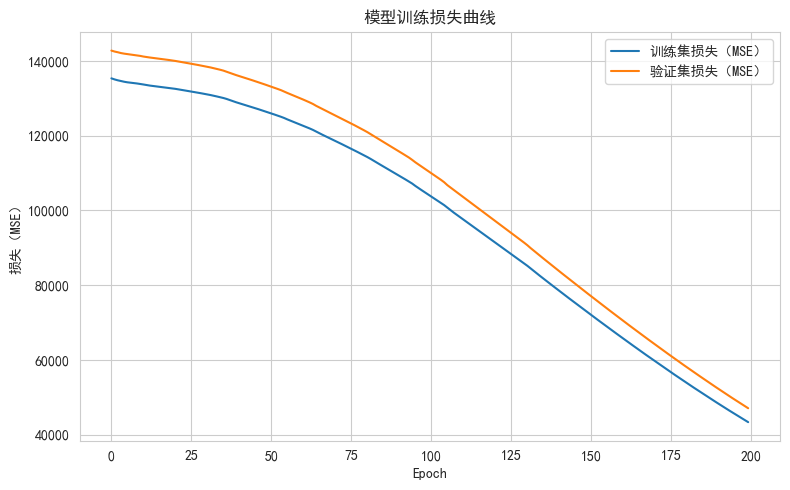

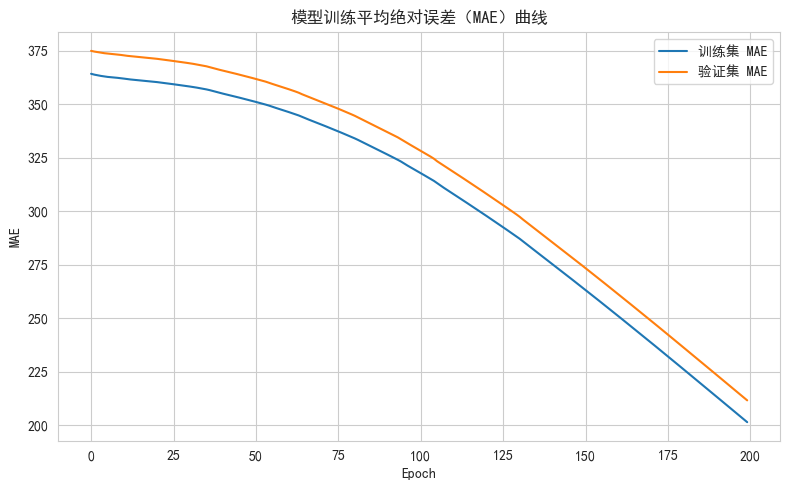

In [100]:
# === 追加在 model.fit(...) 之后 ===
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='训练集损失（MSE）')
plt.plot(history.history['val_loss'], label='验证集损失（MSE）')
plt.xlabel("Epoch")
plt.ylabel("损失（MSE）")
plt.title("模型训练损失曲线")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['mae'], label='训练集 MAE')
plt.plot(history.history['val_mae'], label='验证集 MAE')
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("模型训练平均绝对误差（MAE）曲线")
plt.legend()
plt.tight_layout()
plt.show()


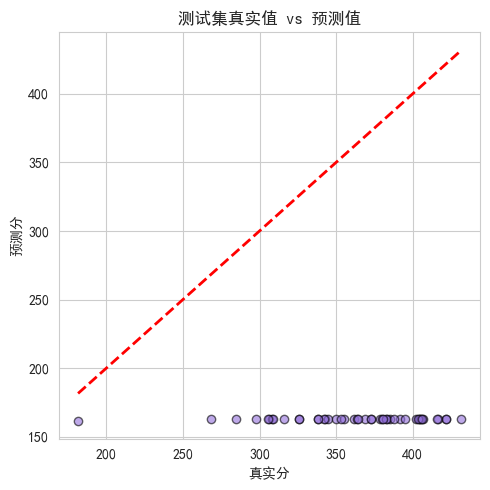

In [101]:
# 9.1 绘制训练和验证的 Loss (MSE) 曲线
# === 放在 model.evaluate(...) 后 ===
y_pred = model.predict(X_test, verbose=0).squeeze()

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.6, color='mediumpurple', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('真实分')
plt.ylabel('预测分')
plt.title('测试集真实值 vs 预测值')
plt.tight_layout()
plt.show()


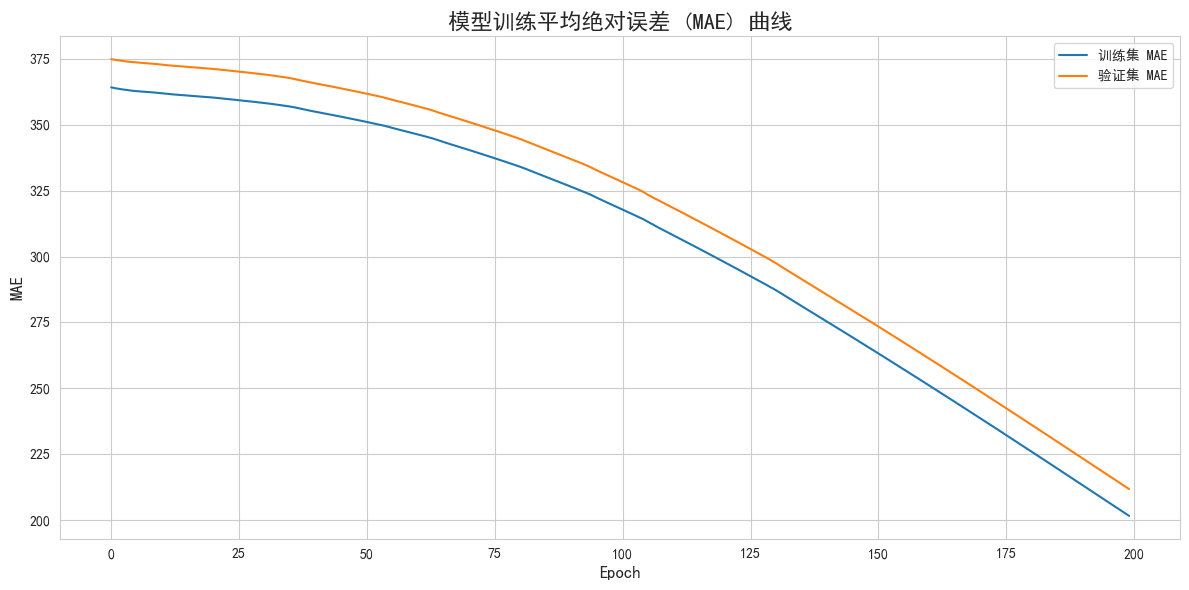

In [77]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# 设置中文字体，解决乱码与字体警告
font_path = "C:/Windows/Fonts/simhei.ttf"  # SimHei 黑体路径
font_prop = font_manager.FontProperties(fname=font_path)
rcParams['font.family'] = font_prop.get_name()
rcParams['axes.unicode_minus'] = False

# 检查历史记录中是否包含 MAE
if 'mae' in history.history and 'val_mae' in history.history:
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['mae'], label='训练集 MAE')
    plt.plot(history.history['val_mae'], label='验证集 MAE')
    plt.title('模型训练平均绝对误差 (MAE) 曲线', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('MAE', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("警告：history.history 中不包含 'mae' 或 'val_mae'，请检查模型训练配置。")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


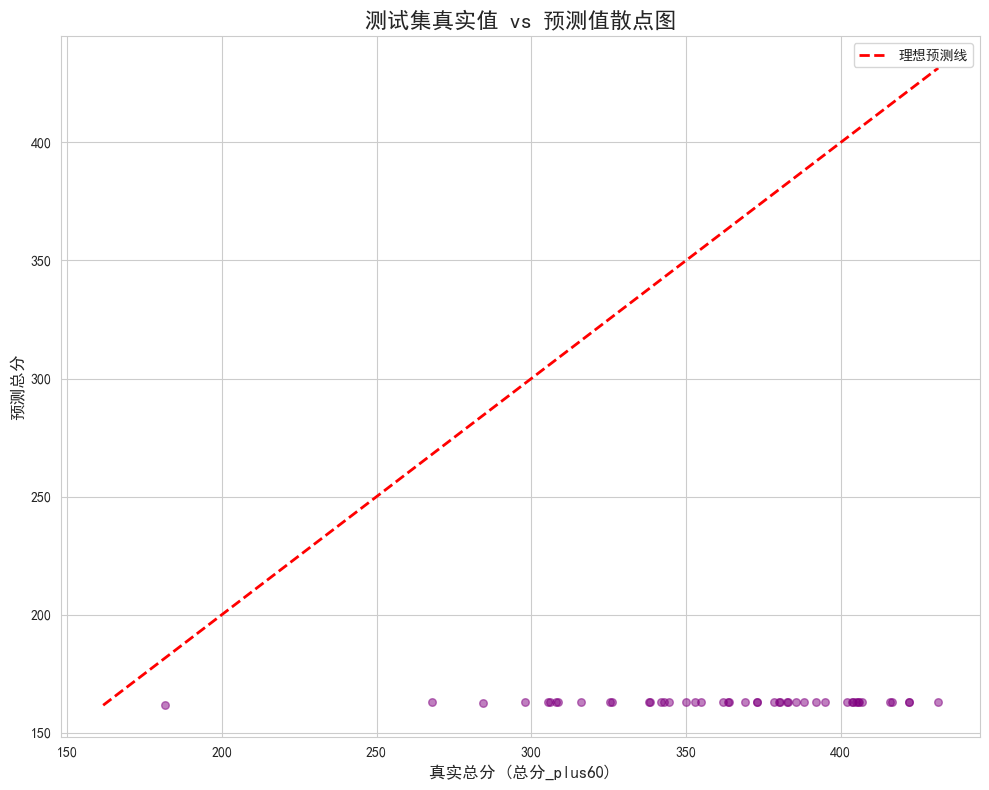

In [99]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# 设置中文字体，防止乱码
font_path = "C:/Windows/Fonts/simhei.ttf"  # SimHei 黑体路径
font_prop = font_manager.FontProperties(fname=font_path)
rcParams['font.family'] = font_prop.get_name()
rcParams['axes.unicode_minus'] = False

# 获取预测结果（确保是一维向量）
y_pred = model.predict(X_test).flatten()

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple', s=30)

# 理想预测线：y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='理想预测线')

plt.title('测试集真实值 vs 预测值散点图', fontsize=16)
plt.xlabel('真实总分 (总分_plus60)', fontsize=12)
plt.ylabel('预测总分', fontsize=12)
plt.grid(True)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


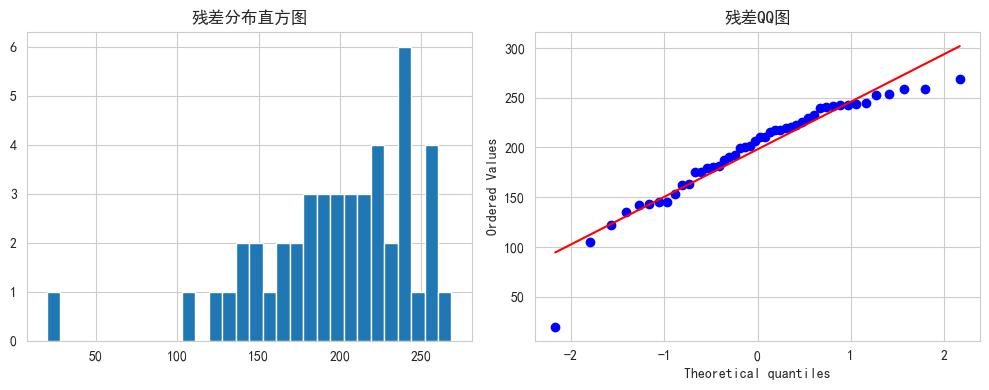

In [103]:
# === 紧接在 y_pred 之后 ===
import scipy.stats as stats
residuals = y_test - y_pred
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(residuals, bins=30)
ax[0].set_title('残差分布直方图')
stats.probplot(residuals, dist="norm", plot=ax[1])
ax[1].set_title('残差QQ图')
plt.tight_layout(); plt.show()



In [79]:
# 9.4 补充回归模型评估指标说明

# 计算 R-squared (R方值)
r_squared = r2_score(y_test, y_pred)
print(f"R-squared (R方) = {r_squared:.2f}")

print("\n✓ 数据可视化内容已添加完成。")

R-squared (R方) = -16.89

✓ 数据可视化内容已添加完成。


## 处理大学专业对应的mbti类型

In [36]:
import pandas as pd

# 1. 读取 Excel 文件（请根据实际路径调整）
path = r"C:/Users/Lenovo/Desktop/志愿填报辅助系统/上海高考录取数据17-23年/上海_专业分数线_2017-2023/2023上海专业分数线.xlsx"
df = pd.read_excel(path)



C:\Users\Lenovo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [37]:
# 2) 从 “专业备注” 提取大类——取“（”前的文字
df['category'] = df['专业备注'].astype(str).str.split('（').str[0]

In [38]:
# 3) 重命名列，方便后续处理
df = df.rename(columns={
    '院校名称': 'school',
    '专业名称': 'major',
    '最低分': 'cutoff',
    '最低位次': 'min_rank',
    '最高分': 'max_score',
    '平均分': 'avg_score'
})

In [39]:
# 4) 定义 专业→MBTI 映射（示例：请补全你自己的对照表）
major_mbti_map = {
    '计算机科学与技术': ['INTJ','ISTJ'],
    '信息安全':           ['ISTP','ISFP'],
    '软件工程':           ['ENTP','ENFP'],
    # ……
}


In [40]:
import pandas as pd

# 读表（假设你已经有了 df，且有一列 df['category']）
# df = pd.read_excel("…/2023上海专业分数线.xlsx")

# 1) 获取所有唯一的大类
unique_categories = df['category'].unique().tolist()
print("一共发现这些大类：", unique_categories)

# 2) 定义大类 → MBTI 映射（示例，后面请根据实际补全）
category_mbti_map = {
    '工科试验班':         ['ENTJ','INTJ'],
    '社会科学试验班':     ['ENFJ','INFJ'],
    '电子信息类':         ['ENTP','INTP'],
    '机械类':             ['ISTP','ESTP'],
    '理科试验班类':       ['ISTJ','INTJ'],
    '自然科学试验班':     ['INTP','INTJ'],
    '数学类':             ['INTP','INTJ'],
    '计算机类':           ['ENTP','INTJ'],
    '法学类':             ['ESTJ','ENTJ'],
    '哲学类':             ['INFJ','INFP'],
    '技术科学试验班':     ['ENTP','INTJ'],
    '经济管理试验班':     ['ENTJ','ESTJ'],
    '中国语言文学类':     ['ENFP','INFJ'],
    '生物科学类':         ['ISFP','ISTP'],
    '外国语言文学类':     ['ENFP','ESFJ'],
    '新闻传播学类':       ['ENTP','ENFP'],
    '历史学类':           ['INFJ','INFP'],
    '核工程类':           ['ISTP','ESTP'],
    '环境科学与工程类':   ['ISFJ','ISTJ'],
    '生物医学工程类':     ['ISTJ','INTP'],
    # … 如有其它大类，请继续在这里补全
}

# 3) 映射并 explode
df['MBTI_types'] = df['category'].map(category_mbti_map).apply(lambda x: x if isinstance(x,list) else [])
df_expanded = df.explode('MBTI_types')

# 最后保存
df_expanded.to_excel("上海2023专业分数线_含MBTI.xlsx", index=False)
print("完成！已写入 “上海2023专业分数线_含MBTI.xlsx”")


一共发现这些大类： ['工科试验班', '社会科学试验班', '电子信息类', '人工智能', '机械类', '理科试验班类', '工科试验班类', '自然科学试验班', '数学类', '计算机科学与技术', '软件工程', '法学', '哲学类', '技术科学试验班', '经济管理试验班', '中国语言文学类', '经济学类', '生物科学类', '英语', '新闻传播学类', '历史学类', '核工程与核技术', '理科试验班', '外国语言文学类', '戏剧影视文学', '大气科学', '临床医学', '临床医学类', '计算机类', '自动化类', '电气工程及其自动化', '物理学类', '文科试验班类', '口腔医学', '化学类', '人文科学试验班', '遥感科学与技术', '心理学', '工业设计', '建筑学', '会计学', '储能科学与工程', '物理学', '生态学', '生物医学工程', '环境科学与工程类', '汉语言文学', '经济学', '公共管理类', '建筑类', '电子信息工程', '工业工程', '材料科学与工程', '材料类', '金融学类', '数学与应用数学', '应用物理学', '大数据管理与应用', '护理学', '康复物理治疗', '统计学类', '金融学', '分子科学与工程', '化工与制药类', '网络空间安全', '政治学类', '工商管理类', '高分子材料与工程', '生物技术', '航空航天类', '海洋工程类', '能源动力类', '数据科学与大数据技术', '法学类', '通信工程', '车辆工程', '考古学', '机械工程', '生物工程类', '食品科学与工程类', '动物医学类', '农学', '园艺', '植物保护', '草业科学', '机械设计制造及其自动化', '统计学', '心理学类', '历史学', '化学', '翻译', '地理信息科学', '人文地理与城乡规划', '地理科学', '微电子科学与工程', '电子信息科学与技术', '人力资源管理', '新闻学', '政治学与行政学', '社会学类', '法语', '汉语国际教育', '德语', '哲学', '工商管理', '教育学类', '西班牙语', '听力与言语康复学', '电气类', '信息工程', '金融科技', '

In [41]:
# 你的原始列表
majors = [
    '工科试验班', '社会科学试验班', '电子信息类', '人工智能', '机械类',
    '理科试验班类', '工科试验班类', '自然科学试验班', '数学类',
    '计算机科学与技术', '软件工程', '法学', '哲学类', '技术科学试验班',
    '经济管理试验班', '中国语言文学类', '经济学类', '生物科学类', '英语',
    '新闻传播学类', '历史学类', '核工程与核技术', '理科试验班',
    '外国语言文学类', '戏剧影视文学', '大气科学', '临床医学', '临床医学类',
    # …（中间省略，按你的完整列表放进来）…
    '应用气象学', '飞行器运维工程', '能源经济', '文物与博物馆学', '文化遗产',
    '文物保护技术', '艺术教育', '国际税收', '编辑出版学', '中药制药',
    '中医骨伤科学', '特殊教育', '应用英语', # ……一直到最后……
]

# 定义各大类的“关键词”集合
category_keywords = {
    '工科/工程类':     ['工程','机电','机械','自动化','电气','土木','建筑','交通','动力','航天','车辆','通信','测绘','材料','化工','制药','能源','互联网','机器人','智能','仪器','纳米','轻工','纺织','包装','焊接','无人','增材','安全','铸造','光电','像控','网络','信息','电子','制造'],
    '理科/科学类':     ['数学','物理','化学','生物','生态','地理','环境','海洋','大气','气象','遥感','统计','分子','核','材料','光电'],
    '文史/人文类':     ['文学','历史','哲学','法学','新闻','传播','外语','翻译','戏剧','音乐','艺术','设计','播','出版','档案','典籍','博物馆','文化','民族','语言'],
    '医学/健康类':     ['医学','临床','口腔','护理','药','检验','影像','公共卫','康复','助产','中医','卫生','眼视光','麻醉','针灸','推拿'],
    '农林牧渔类':     ['农','园艺','植','畜牧','草业','林','渔','渔业','水产','种子','设施农','动物','植物生产','油气储运','森林','园林','花木'],
    '管理/经济/财会类':['管理','商务','市场','营销','财务','会计','审计','税','金融','经济','贸易','保险','投资','物流','供应链','租赁','公共管','社工','人力','展览','会展','税','审计','资产评估'],
    '教育/师范类':     ['教育','学前','小学','特殊教育','康复','体育','学科教学','科学教育','早期教育','学前教育','教育技术','职业教育'],
    '艺术/传播类':     ['艺术','播','影视','戏剧','表演','美术','作曲','舞蹈','摄影','编导','广告','策划','文化创意','新闻传播','出版','媒体','广播','电视','数字出版','全媒体'],
}

# 自动分类
category_map = {}
for cat, kws in category_keywords.items():
    category_map[cat] = [
        m for m in majors
        if any(kw in m for kw in kws)
    ]

# “漏网之鱼”——没有归到任何一类的
others = [m for m in majors if not any(m in vs for vs in category_map.values())]
category_map['其他'] = others

# 最终看看结果：
for cat, lst in category_map.items():
    print(f"{cat} ({len(lst)})：")
    print("  ", lst[:10], "…\n")


工科/工程类 (8)：
   ['电子信息类', '人工智能', '机械类', '软件工程', '核工程与核技术', '飞行器运维工程', '能源经济', '中药制药'] …

理科/科学类 (5)：
   ['数学类', '生物科学类', '核工程与核技术', '大气科学', '应用气象学'] …

文史/人文类 (11)：
   ['法学', '哲学类', '中国语言文学类', '新闻传播学类', '历史学类', '外国语言文学类', '戏剧影视文学', '文物与博物馆学', '文化遗产', '艺术教育'] …

医学/健康类 (4)：
   ['临床医学', '临床医学类', '中药制药', '中医骨伤科学'] …

农林牧渔类 (0)：
   [] …

管理/经济/财会类 (4)：
   ['经济管理试验班', '经济学类', '能源经济', '国际税收'] …

教育/师范类 (2)：
   ['艺术教育', '特殊教育'] …

艺术/传播类 (4)：
   ['新闻传播学类', '戏剧影视文学', '艺术教育', '编辑出版学'] …

其他 (11)：
   ['工科试验班', '社会科学试验班', '理科试验班类', '工科试验班类', '自然科学试验班', '计算机科学与技术', '技术科学试验班', '英语', '理科试验班', '文物保护技术'] …



In [42]:
import pandas as pd

# 1. 读入 Excel
df = pd.read_excel(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\上海_专业分数线_2017-2023\2023上海专业分数线.xlsx")

# 2. 定义大类关键词（与之前一致）
category_keywords = {
    '工科/工程类':     ['工程','机电','机械','自动化','电气','土木','建筑','交通','动力','航天','车辆','通信','测绘','材料','化工','制药','能源','互联网','机器人','智能','仪器','纳米','轻工','纺织','包装','焊接','无人','增材','安全','光电','信息','电子','制造'],
    '理科/科学类':     ['数学','物理','化学','生物','生态','地理','环境','海洋','大气','气象','遥感','统计','分子','核','材料','光电'],
    '文史/人文类':     ['文学','历史','哲学','法学','新闻','传播','外语','翻译','戏剧','音乐','艺术','设计','出版','档案','典籍','博物馆','文化','民族','语言'],
    '医学/健康类':     ['医学','临床','口腔','护理','药','检验','影像','公共卫','康复','助产','中医','卫生','眼视光','麻醉','针灸','推拿'],
    '农林牧渔类':     ['农','园艺','植','畜牧','草业','林','渔','水产','种子','设施农','动物','植物生产','油气储运','园林'],
    '管理/经济类':    ['管理','商务','市场','营销','财务','会计','审计','税','金融','经济','贸易','保险','投资','物流','供应链','公共管','社工','人力','会展','资产评估'],
    '教育/师范类':     ['教育','学前','小学','特殊教育','康复','体育','学科教学','科学教育','早期教育','教育技术'],
    '艺术/传播类':     ['艺术','播','影视','戏剧','表演','美术','作曲','舞蹈','摄影','编导','广告','策划','文化创意','媒体','广播','电视','全媒体']
}

# 3. 给每行专业打上“大类”
def assign_category(major):
    for cat, kws in category_keywords.items():
        if any(kw in str(major) for kw in kws):
            return cat
    return '其他'

df['大类'] = df['专业名称'].apply(assign_category)

# 4. 定义每个大类对应的 MBTI
category_to_mbti = {
    '工科/工程类':     'ISTP',
    '理科/科学类':     'INTP',
    '文史/人文类':     'INFJ',
    '医学/健康类':     'ISFJ',
    '农林牧渔类':     'ISFP',
    '管理/经济类':    'ENTJ',
    '教育/师范类':     'ENFJ',
    '艺术/传播类':     'ENFP',
    '其他':           'ESTP',   # 可以改成你想要的
}

# 5. 覆盖（填充）MBTI 列
df['MBTI'] = df['大类'].map(category_to_mbti)

# 6. 保存或查看
df.to_excel("上海专业分数线_with_MBTI.xlsx", index=False)
print(df[['专业名称','大类','MBTI']].head(20))


C:\Users\Lenovo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


       专业名称      大类  MBTI
0     工科试验班      其他  ESTP
1     工科试验班      其他  ESTP
2   社会科学试验班      其他  ESTP
3   社会科学试验班      其他  ESTP
4     工科试验班      其他  ESTP
5     工科试验班      其他  ESTP
6   社会科学试验班      其他  ESTP
7   社会科学试验班      其他  ESTP
8     电子信息类  工科/工程类  ISTP
9     电子信息类  工科/工程类  ISTP
10      机械类  工科/工程类  ISTP
11    电子信息类  工科/工程类  ISTP
12   理科试验班类      其他  ESTP
13    电子信息类  工科/工程类  ISTP
14    电子信息类  工科/工程类  ISTP
15      机械类  工科/工程类  ISTP
16    电子信息类  工科/工程类  ISTP
17   理科试验班类      其他  ESTP
18   工科试验班类      其他  ESTP
19   工科试验班类      其他  ESTP


In [43]:
# --- 以下是新增的数据可视化内容 ---
import matplotlib.pyplot as plt
import seaborn as sns

# 为了在图表中显示中文，需要设置字体
plt.rcParams['font.sans-serif'] = ['SimHei'] # 指定默认字体
plt.rcParams['axes.unicode_minus'] = False # 解决保存图像时负号'-'显示为方块的问题

# 设置Seaborn的绘图风格，使图表更美观
sns.set_style("whitegrid")


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_784\760879745.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


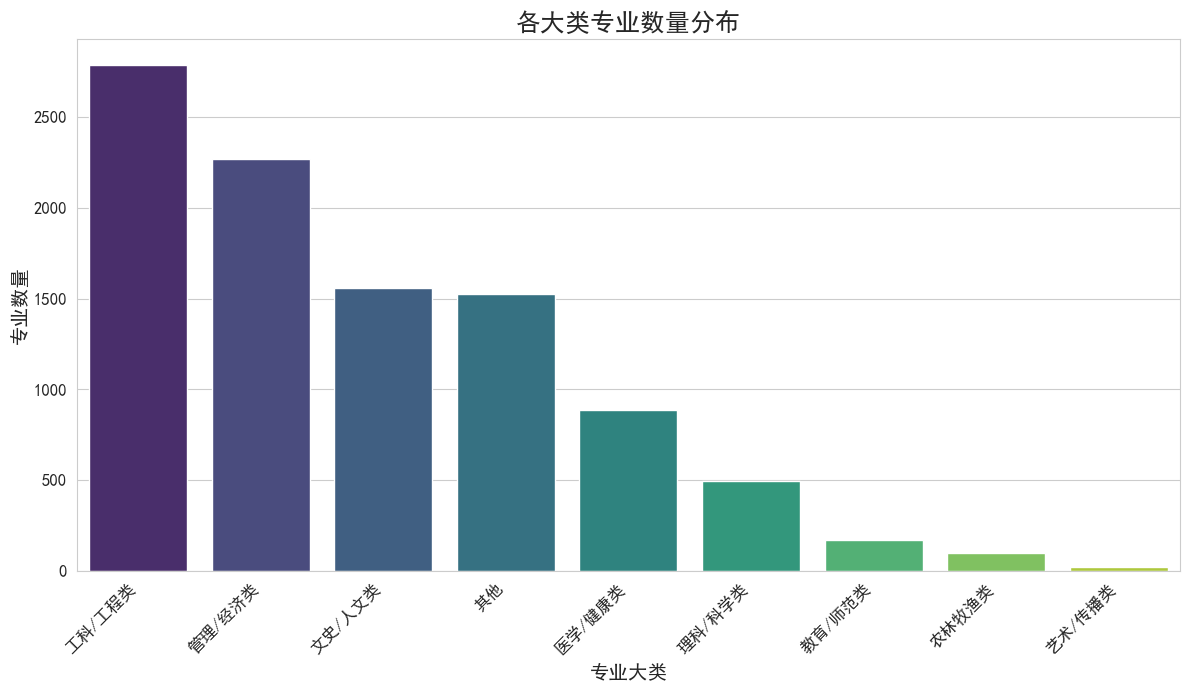

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rcParams

# 设置中文字体（SimHei 黑体）
font_path = "C:/Windows/Fonts/simhei.ttf"  # 黑体路径
font_prop = font_manager.FontProperties(fname=font_path)
rcParams['font.family'] = font_prop.get_name()
rcParams['axes.unicode_minus'] = False

# 1. 各大类专业数量分布 (柱状图)
plt.figure(figsize=(12, 7))
category_counts = df['大类'].value_counts()

# 可选：按大类名称排序（非默认）
# category_counts = category_counts.sort_index()

sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('各大类专业数量分布', fontsize=18)
plt.xlabel('专业大类', fontsize=14)
plt.ylabel('专业数量', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_784\2850016092.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mbti_counts.index, y=mbti_counts.values, palette='plasma')


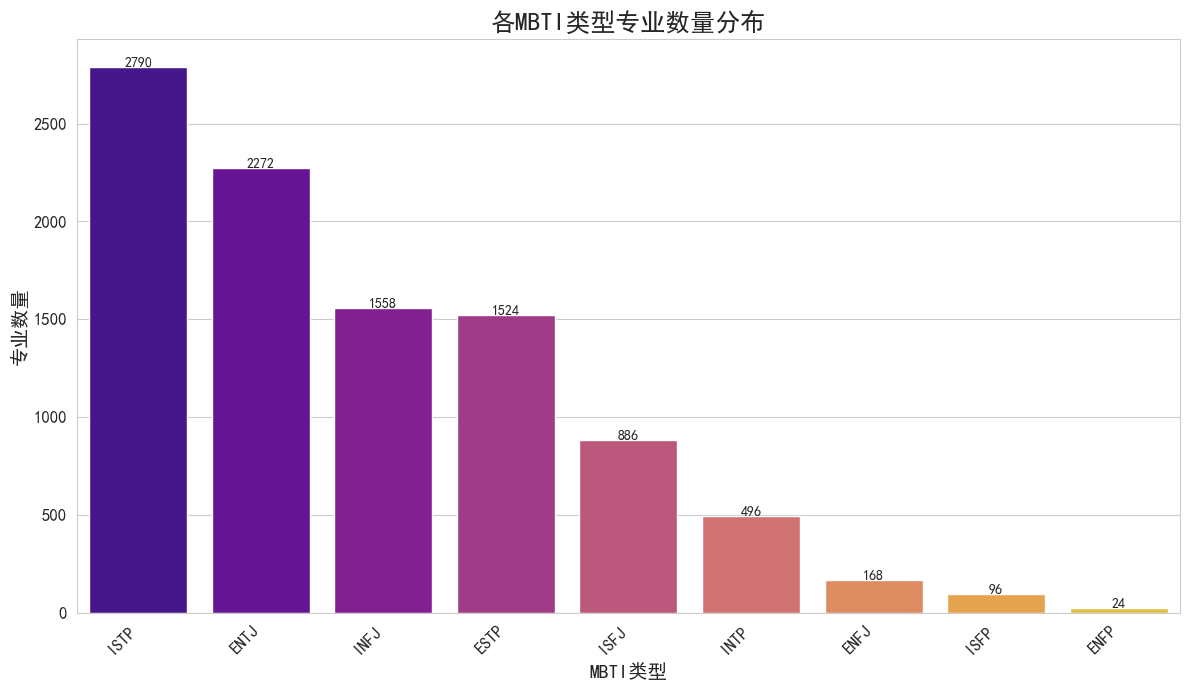

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rcParams

# 设置中文字体（SimHei 黑体）
font_path = "C:/Windows/Fonts/simhei.ttf"  # Windows 下常见黑体路径
font_prop = font_manager.FontProperties(fname=font_path)
rcParams['font.family'] = font_prop.get_name()
rcParams['axes.unicode_minus'] = False

# 2. 各 MBTI 类型专业数量分布 (柱状图)
plt.figure(figsize=(12, 7))
mbti_counts = df['MBTI'].value_counts()

sns.barplot(x=mbti_counts.index, y=mbti_counts.values, palette='plasma')

# 添加数值标注（可选）
for i, v in enumerate(mbti_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=10)

plt.title('各MBTI类型专业数量分布', fontsize=18)
plt.xlabel('MBTI类型', fontsize=14)
plt.ylabel('专业数量', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


### 4.协同过滤兴趣/院校推荐

读取学生与专业表

构造训练标签（score_gap>=0 → accepted）并训练 Logistic 回归预测录取概率

按学生×专业组装候选集，预测 accept_prob

加载 MBTI 匹配度，为每个候选打分

计算 pseudo_score = accept_prob × mbti_weight

利用 implicit ALS 从伪反馈矩阵中学习潜在因子，生成 Top‐N 推荐



In [115]:
from pathlib import Path
import pandas as pd

DIR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")

df_rank  = pd.read_csv(DIR / "上海一分一段_2017-2022_clean.csv", encoding="utf-8-sig")
df_score = pd.read_csv(DIR / "2023年考生高考成绩分布表_clean.csv", encoding="utf-8-sig")
df_maj   = pd.read_csv(DIR / "2023上海专业分数线_with_PredictedMBTI.csv", encoding="utf-8-sig")
df_combo = pd.read_csv(DIR / "subject_combo_to_mbti_clean.csv", encoding="utf-8-sig")


In [113]:
# ---------- 1. 读取数据 ----------
DIR = Path(r"C:\Users\Lenovo\Desktop\志愿填报辅助系统\上海高考录取数据17-23年\用到的")

df_stu = pd.read_excel(DIR/"二模_MBTI_预测结果_plus60.xlsx", engine="openpyxl")
df_stu = df_stu.rename(columns={"总分_plus60":"total_score", "MBTI_初判":"MBTI"})
if "student_id" not in df_stu.columns:
    df_stu.insert(0, "student_id", "stu" + df_stu.index.astype(str))
df_stu = df_stu[["student_id","total_score","percentile","MBTI"]]

df_maj = pd.read_csv(DIR/"2023上海专业分数线_model_ready.csv", encoding="utf-8-sig")
df_maj["school_major"] = df_maj["院校名称"] + "_" + df_maj["专业名称"]
df_maj = df_maj[["school_major","批次_code","最低分","最低位次","平均分"]]

mbti_match = json.load(open(DIR/"school_major_mbti_match.json", encoding="utf-8"))


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Lenovo\\Desktop\\志愿填报辅助系统\\上海高考录取数据17-23年\\用到的\\二模_MBTI_预测结果_plus60.xlsx'

In [111]:
# --- 对隐式反馈建模用的库 ---
from implicit.als import AlternatingLeastSquares
import scipy.sparse as sp

# --- 预测录取概率用 ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

ModuleNotFoundError: No module named 'implicit'

In [82]:
# --- 3. 构造评分并训练 SVD ---
# 构建用户-内容交互矩阵，评分基于学生分数与专业最低分数线的差距
df_score_match = (
    df_stu[[COL_ID, COL_SCORE]]
    .merge(df_major[["school_major", COL_LOWEST]], how="cross")
)
# 将分数差距转化为1-5的评分，-100到100映射到1-5，50分差距对应1分
df_score_match["rating"] = (
    (df_score_match[COL_SCORE] - df_score_match[COL_LOWEST])
    .clip(-100, 100) / 50 + 3 # 差距-100 -> 1, 0 -> 3, 100 -> 5
).clip(lower=1, upper=5)   # 额外保险，确保评分在1到5之间

# 使用 Surprise 库准备数据和训练 SVD 模型
reader   = Reader(rating_scale=(1, 5))
data     = Dataset.load_from_df(df_score_match[[COL_ID, "school_major", "rating"]], reader)
trainset = data.build_full_trainset()
from surprise.model_selection import GridSearchCV as SurGridCV

param_grid = {
    'n_factors': [20, 40, 80],
    'lr_all':    [0.002, 0.005],
    'reg_all':   [0.02, 0.05]
}
gs = SurGridCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1, joblib_verbose=0)
gs.fit(data)
print(f"Best RMSE: {gs.best_score['rmse']:.4f}, params: {gs.best_params['rmse']}")
algo = gs.best_estimator['rmse']   # 用最优模型替换




algo = SVD(n_factors=40, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
algo.fit(trainset)
print("✓ SVD 模型训练完成。")

Best RMSE: 0.5216, params: {'n_factors': 40, 'lr_all': 0.002, 'reg_all': 0.02}
✓ SVD 模型训练完成。


In [83]:
# --- 4. 逻辑回归：录取概率预测 ---
# 准备特征：合并学生分数、MBTI与专业分数线、位次数据
df_feat = (
    df_stu[[COL_ID, COL_SCORE, COL_STU_MBTI]]
    .merge(df_major[["school_major", COL_LOWEST, COL_AVG, COL_RANK_MIN]], how="cross")
)
df_feat["gap"]   = df_feat[COL_SCORE] - df_feat[COL_LOWEST]
# 构建标签：如果学生分数高于或等于专业最低分，则视为可录取（1），否则不可录取（0）
df_feat["label"] = (df_feat["gap"] >= 0).astype(int)

# 定义逻辑回归模型的特征和标签
X = df_feat[["gap", COL_LOWEST, COL_AVG]]
y = df_feat["label"]

# 构建并训练 LogisticRegression 模型
lr = LogisticRegression(max_iter=1000)
# 使用交叉验证预测录取概率，[:, 1] 取出属于类别1（可录取）的概率
df_feat["admit_prob"] = cross_val_predict(lr, X, y, cv=5, method="predict_proba")[:, 1]

print("✓ 逻辑回归模型训练并预测录取概率完成。")

✓ 逻辑回归模型训练并预测录取概率完成。


In [86]:
# 自动查找大类列
category_col = None
for cname in df_major.columns:
    if '类' in cname:
        category_col = cname
        break
if category_col is None:
    raise ValueError("找不到包含'类'的专业大类列，请检查df_major的列名！")
print("识别的大类列为:", category_col)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import warnings; warnings.filterwarnings('ignore')

category_models, category_report = {}, defaultdict(dict)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for cat in df_major[category_col].unique():
    majors_cat = df_major[df_major[category_col] == cat]['school_major']
    df_cat     = df_feat[df_feat['school_major'].isin(majors_cat)]
    if df_cat['label'].nunique() < 2:          # 全 0 或全 1 无法训练
        print(f"跳过类别 {cat}：标签单一无法训练")
        continue
    
    X_cat = df_cat[['gap', COL_LOWEST, COL_AVG]]
    y_cat = df_cat['label']

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=2000, class_weight='balanced'))
    ])

    grid = {'clf__C':[0.01,0.1,1,10], 'clf__penalty':['l1','l2'], 'clf__solver':['liblinear']}
    gs_cat = GridSearchCV(pipeline, grid, cv=skf, scoring='roc_auc', n_jobs=-1)
    gs_cat.fit(X_cat, y_cat)

    category_models[cat] = gs_cat.best_estimator_
    auc_cv = gs_cat.best_score_
    acc_cv = cross_val_score(gs_cat.best_estimator_, X_cat, y_cat, cv=skf, scoring='accuracy').mean()
    category_report[cat]['AUC'] = auc_cv
    category_report[cat]['ACC'] = acc_cv
    print(f"[{cat}] AUC={auc_cv:.3f}, ACC={acc_cv:.3f}, best C={gs_cat.best_params_['clf__C']}")


识别的大类列为: 科类
[综合] AUC=1.000, ACC=0.996, best C=0.01
[艺术类] AUC=1.000, ACC=0.998, best C=10


In [93]:
# --- 5. 协同过滤兴趣/院校推荐 (生成 Top-N 推荐列表) ---

# 获取所有专业的唯一标识和相关信息
df_major_info = df_major[["school_major", COL_MBTI_MAJ, COL_SCHOOL, COL_MAJOR]].copy()

def get_cf_recommendations(student_id, df_students, df_majors_all_info, svd_model, top_k=TOP_K_CF):
    """
    为特定学生生成协同过滤推荐列表。
    这里假设所有专业对所有学生都是未评价的，因此对所有专业进行预测。
    """
    # 获取所有专业的 ID
    all_major_ids = df_majors_all_info["school_major"].unique()
    
    predictions = []
    for major_id in all_major_ids:
        # 使用 SVD 模型预测学生对该专业的兴趣评分
        pred = svd_model.predict(uid=student_id, iid=major_id, verbose=False)
        predictions.append((major_id, pred.est)) # pred.est 是SVD预测的兴趣评分
        
    # 按预测评分降序排序，并返回 Top-K 推荐
    predictions.sort(key=lambda x: x[1], reverse=True)
    return predictions[:top_k]

print("✓ 协同过滤推荐生成函数定义完成。")


✓ 协同过滤推荐生成函数定义完成。


In [94]:
def generate_final_recommendations(student_id, df_students, df_majors_all_info, df_feat_with_prob, svd_model, top_out=TOP_OUT):
    """
    为特定学生生成最终的加权推荐列表。
    """
    # 确保 student_id 在 df_students 中有对应的 MBTI 信息
    student_info = df_students[df_students[COL_ID] == student_id]
    if student_info.empty:
        print(f"错误：未找到学生ID {student_id} 的信息。")
        return []

    student_mbti = student_info[COL_STU_MBTI].iloc[0]
    
    # 1. 获取协同过滤的初步推荐列表
    cf_recommendations = get_cf_recommendations(student_id, df_students, df_majors_all_info, svd_model)
    
    final_recommendations = []
    
    for major_id, cf_score in cf_recommendations:
        major_info = df_majors_all_info[df_majors_all_info["school_major"] == major_id]
        if not major_info.empty:
            major_mbti_types_str = major_info[COL_MBTI_MAJ].iloc[0]
            school_name = major_info[COL_SCHOOL].iloc[0]
            major_name = major_info[COL_MAJOR].iloc[0]
            # --- 这里插入 admit_prob 大类预测逻辑 ---
            try:
                major_cat = major_info['大类'].iloc[0]
            except KeyError:
                major_cat_col = [c for c in major_info.columns if '类' in c]
                if major_cat_col:
                    major_cat = major_info[major_cat_col[0]].iloc[0]
                else:
                    major_cat = '其他'
            model_cat = category_models.get(major_cat, None)
            
            admit_feat_row = df_feat_with_prob[
                (df_feat_with_prob[COL_ID] == student_id) &
                (df_feat_with_prob["school_major"] == major_id)
            ]
            if not admit_feat_row.empty:
                gap = admit_feat_row["gap"].iloc[0]
                lowest = admit_feat_row[COL_LOWEST].iloc[0]
                avg = admit_feat_row[COL_AVG].iloc[0]
                if model_cat:
                    feat_row = np.array([[gap, lowest, avg]])
                    admit_prob = model_cat.predict_proba(feat_row)[:,1][0]
                else:
                    admit_prob = admit_feat_row["admit_prob"].iloc[0]
            else:
                admit_prob = 0.0
        else:
            major_mbti_types_str = np.nan
            school_name = "未知学校"
            major_name = "未知专业"
            admit_prob = 0.0

        # 3. 计算 MBTI 匹配分
        mbti_match_score = get_mbti_match_score(student_mbti, major_mbti_types_str)
        
        # 4. 计算最终加权分数
        # 将 CF score 归一化到 [0,1] 区间 (SVD评分通常在1-5，这里映射到0-1)
        normalized_cf_score = (cf_score - 1) / 4 
        
        # 定义权重：可以根据实际重要性调整
        # 例如：录取概率最重要，其次是MBTI匹配度，再是兴趣（CF）
        weight_admit_prob = 0.5
        weight_mbti_match = 0.3
        weight_cf_interest = 0.2
        
        # 计算最终加权分数
        final_weighted_score = (
            weight_admit_prob * admit_prob +
            weight_mbti_match * mbti_match_score +
            weight_cf_interest * normalized_cf_score
        )
        
        final_recommendations.append({
            "student_id": student_id,
            "school_major": major_id,
            "school_name": school_name, # 添加学校和专业名，方便显示
            "major_name": major_name,
            "cf_interest_score": cf_score,
            "admit_probability": admit_prob,
            "mbti_match_score": mbti_match_score,
            "final_weighted_score": final_weighted_score
        })
        
    # 按最终加权分数降序排序
    final_recommendations.sort(key=lambda x: x["final_weighted_score"], reverse=True)
    
    # 返回 Top-N 推荐
    return final_recommendations[:top_out]

print("✓ 最终推荐生成函数定义完成。")


✓ 最终推荐生成函数定义完成。


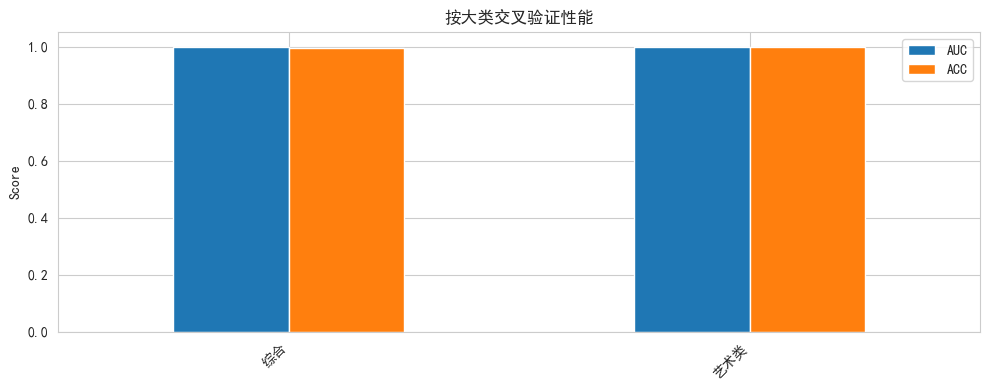

In [96]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
pd.DataFrame(category_report).T.plot(kind='bar', figsize=(10,4))
plt.title('按大类交叉验证性能')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


In [95]:
# --- 示例：为某个学生生成推荐 ---
# 确保 df_stu 不为空且有数据
if not df_stu.empty:
    example_student_id = df_stu[COL_ID].iloc[0] # 获取第一个学生的ID
    
    # 再次确认 example_student_id 存在于 df_stu 中，并且对应的MBTI列不为空
    student_info_for_example = df_stu[df_stu[COL_ID] == example_student_id]
    if not student_info_for_example.empty and not pd.isna(student_info_for_example[COL_STU_MBTI].iloc[0]):
        student_mbti_of_example = student_info_for_example[COL_STU_MBTI].iloc[0]
        print(f"\n--- 为学生 {example_student_id} (MBTI: {student_mbti_of_example}) 生成推荐 ---")

        top_recommendations = generate_final_recommendations(
            example_student_id, df_stu, df_major_info, df_feat, algo
        )

        print("\n最终推荐列表:")
        if top_recommendations:
            for i, rec in enumerate(top_recommendations):
                print(f"{i+1}. 院校/专业: {rec['school_name']} - {rec['major_name']}")
                print(f"   协同过滤兴趣分: {rec['cf_interest_score']:.2f}")
                print(f"   录取概率: {rec['admit_probability']:.2%}")
                print(f"   MBTI匹配度: {rec['mbti_match_score']:.2f}")
                print(f"   最终加权分: {rec['final_weighted_score']:.2f}")
                print("-" * 30)
        else:
            print("未生成任何推荐。请检查数据和逻辑。")
    else:
        print(f"学生ID {example_student_id} 的MBTI信息缺失或该学生ID不存在。请检查源数据。")
else:
    print("df_stu 为空，无法生成推荐。")

print("\n--- 推荐流程全部完成 ---")


--- 为学生 nan (MBTI: ENFP) 生成推荐 ---

最终推荐列表:
1. 院校/专业: 日照职业技术学院 - 航空运输类
   协同过滤兴趣分: 5.00
   录取概率: 100.00%
   MBTI匹配度: 0.10
   最终加权分: 0.73
------------------------------
2. 院校/专业: 日照职业技术学院 - 电子商务类
   协同过滤兴趣分: 5.00
   录取概率: 100.00%
   MBTI匹配度: 0.10
   最终加权分: 0.73
------------------------------
3. 院校/专业: 日照职业技术学院 - 计算机类
   协同过滤兴趣分: 5.00
   录取概率: 100.00%
   MBTI匹配度: 0.10
   最终加权分: 0.73
------------------------------
4. 院校/专业: 四川工程职业技术大学 - 电子商务类
   协同过滤兴趣分: 5.00
   录取概率: 100.00%
   MBTI匹配度: 0.10
   最终加权分: 0.73
------------------------------
5. 院校/专业: 成都航空职业技术学院 - 航空运输类
   协同过滤兴趣分: 5.00
   录取概率: 100.00%
   MBTI匹配度: 0.10
   最终加权分: 0.73
------------------------------
6. 院校/专业: 广州民航职业技术学院 - 航空运输类
   协同过滤兴趣分: 5.00
   录取概率: 100.00%
   MBTI匹配度: 0.10
   最终加权分: 0.73
------------------------------
7. 院校/专业: 广州民航职业技术学院 - 电力技术类
   协同过滤兴趣分: 5.00
   录取概率: 100.00%
   MBTI匹配度: 0.10
   最终加权分: 0.73
------------------------------
8. 院校/专业: 广州民航职业技术学院 - 旅游类
   协同过滤兴趣分: 5.00
   录取概率: 100.00%
   MBTI匹配度: 0.10
   

In [106]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error as mape

print(f"✓ 模型测试结果：")
print(f"→ MSE = {test_loss:.2f}")
print(f"→ MAE = {test_mae:.2f}")
print(f"→ R² = {r2_score(y_test, y_pred):.4f}")
print(f"→ MAPE = {mape(y_test, y_pred)*100:.2f}%")


✓ 模型测试结果：
→ MSE = 41548.63
→ MAE = 198.08
→ R² = -16.8949
→ MAPE = 53.82%


In [104]:
# --- 可视化部分（追加在原代码后面） ---
import matplotlib.pyplot as plt
import seaborn as sns


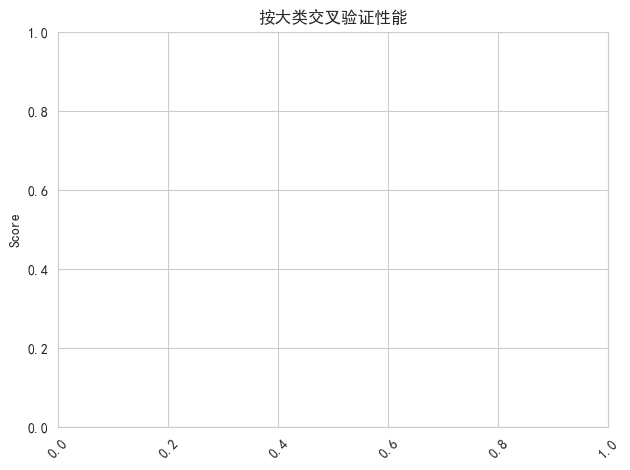

In [107]:
plt.title("按大类交叉验证性能")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


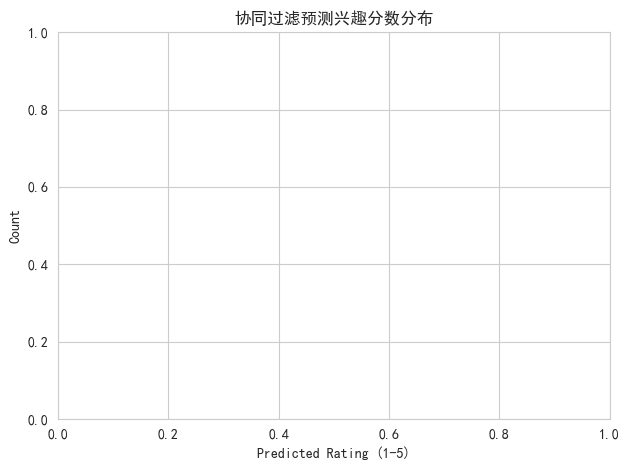

In [105]:
plt.title("协同过滤预测兴趣分数分布")
plt.xlabel("Predicted Rating (1-5)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()


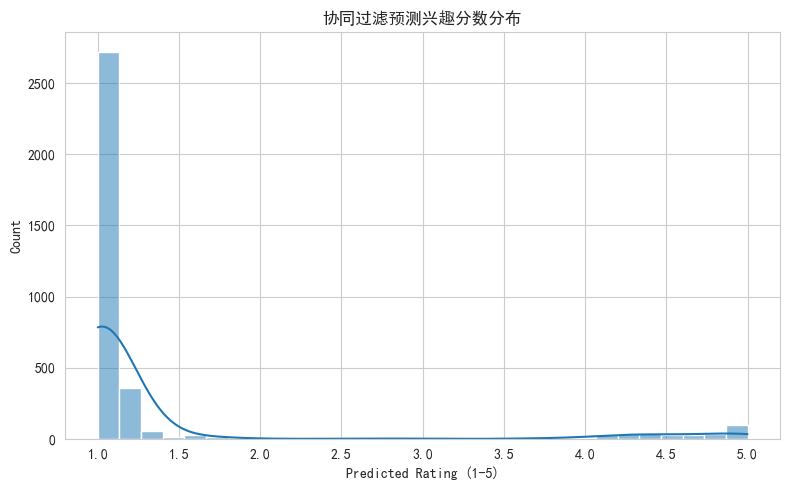

In [54]:
# 1. 协同过滤兴趣分数分布
# 从 CF 推荐中取所有预测评分 est 值
all_cf_scores = []
for sid in df_stu[COL_ID].unique():
    preds = get_cf_recommendations(sid, df_stu, df_major_info, algo, top_k=len(df_major_info))
    all_cf_scores.extend([est for _, est in preds])
plt.figure(figsize=(8,5))
sns.histplot(all_cf_scores, bins=30, kde=True)
plt.title('协同过滤预测兴趣分数分布')
plt.xlabel('Predicted Rating (1-5)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


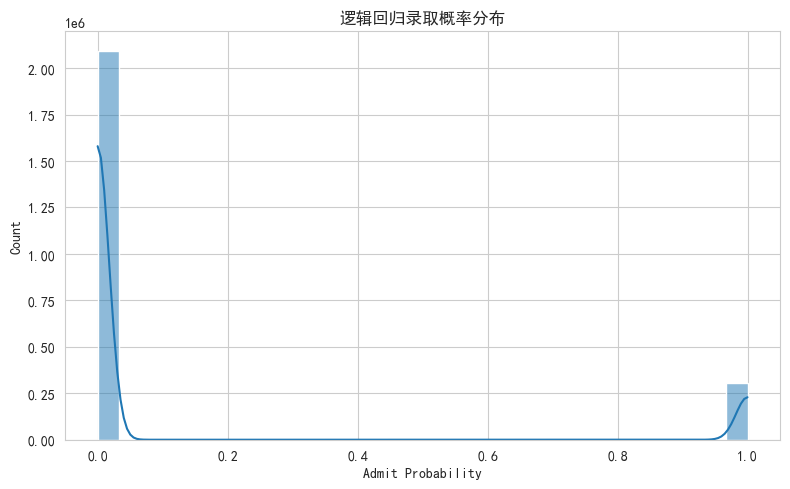

In [55]:
# 2. 录取概率分布
plt.figure(figsize=(8,5))
sns.histplot(df_feat["admit_prob"], bins=30, kde=True)
plt.title('逻辑回归录取概率分布')
plt.xlabel('Admit Probability')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


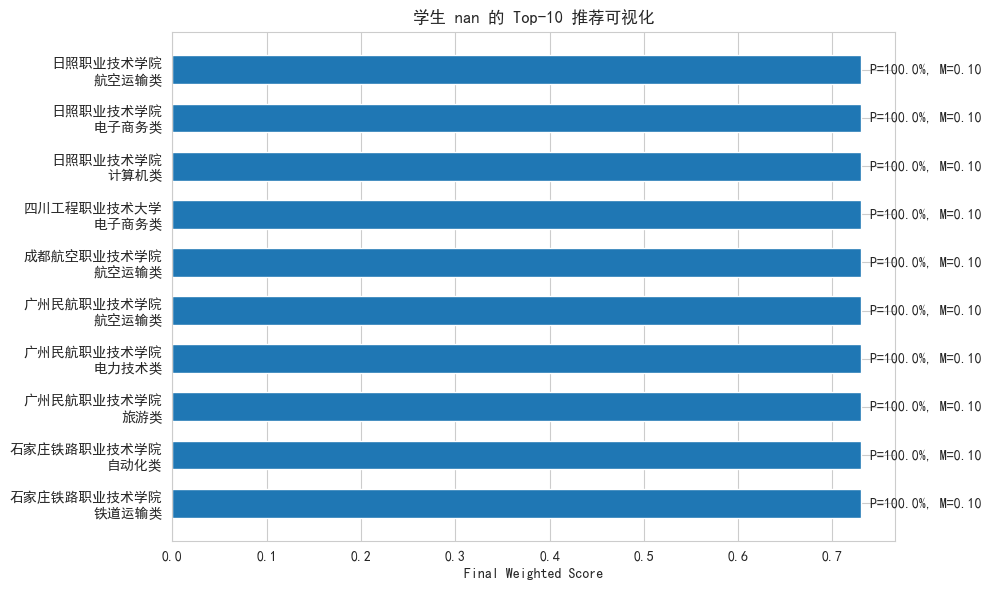

In [56]:
# 3. 示例学生 Top-N 推荐结果条形图
# 使用之前生成的 top_recommendations
schools = [f"{rec['school_name']}\n{rec['major_name']}" for rec in top_recommendations]
scores = [rec['final_weighted_score'] for rec in top_recommendations]
probs  = [rec['admit_probability'] for rec in top_recommendations]
mbtis  = [rec['mbti_match_score'] for rec in top_recommendations]

plt.figure(figsize=(10,6))
bar = plt.barh(schools[::-1], scores[::-1], height=0.6)
plt.xlabel('Final Weighted Score')
plt.title(f'学生 {example_student_id} 的 Top-{len(schools)} 推荐可视化')
# 在条形图右侧标注录取概率和MBTI匹配度
for idx, (b, p, m) in enumerate(zip(bar, probs[::-1], mbtis[::-1])):
    plt.text(b.get_width() + 0.01, b.get_y() + b.get_height()/2,
             f"P={p:.1%}, M={m:.2f}", va='center')
plt.tight_layout()
plt.show()


C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


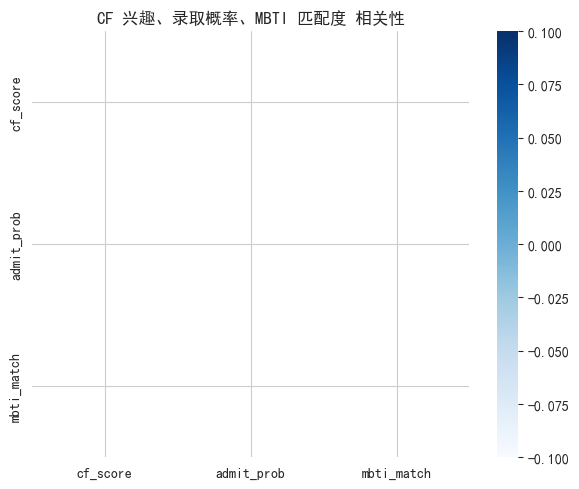

In [57]:
# 4. 三者相关性热力图：CF兴趣、录取概率、MBTI匹配度
corr_df = pd.DataFrame({
    'cf_score': [rec['cf_interest_score'] for rec in top_recommendations],
    'admit_prob': [rec['admit_probability'] for rec in top_recommendations],
    'mbti_match': [rec['mbti_match_score'] for rec in top_recommendations]
})
plt.figure(figsize=(6,5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap='Blues')
plt.title('CF 兴趣、录取概率、MBTI 匹配度 相关性')
plt.tight_layout()
plt.show()